## Import Libraries

In [1]:
import os
import re
import copy
import shutil
import time
import pprint
import warnings

import torch
import torchio as tio
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set()
sns.set_style("whitegrid", {'axes.grid' : True})
plt.style.use('default')
warnings.filterwarnings('ignore')

torch.manual_seed(14041931)
print('TorchIO version:', tio.__version__)
print('Last run on', time.ctime())

TorchIO version: 0.19.8
Last run on Fri Nov  8 15:48:45 2024


## Visualization Functions

In [3]:
#@title Visualization Functions
def get_bounds(self):
    """Get image bounds in mm.

    Returns:
        np.ndarray: [description]
    """
    first_index = 3 * (-0.5,)
    last_index = np.array(self.spatial_shape) - 0.5
    first_point = nib.affines.apply_affine(self.affine, first_index)
    last_point = nib.affines.apply_affine(self.affine, last_index)
    array = np.array((first_point, last_point))
    bounds_x, bounds_y, bounds_z = array.T.tolist()
    return bounds_x, bounds_y, bounds_z

def to_pil(image):
    from PIL import Image
    from IPython.display import display
    data = image.numpy().squeeze().T
    data = data.astype(np.uint8)
    image = Image.fromarray(data)
    w, h = image.size
    display(image)
    print()  # in case multiple images are being displayed

def stretch(img):
    p1, p99 = np.percentile(img, (1, 99))
    from skimage import exposure
    img_rescale = exposure.rescale_intensity(img, in_range=(p1, p99))
    return img_rescale

def show_fpg(
        subject,
        to_ras=False,
        stretch_slices=True,
        indices=None,
        intensity_name='t1',
        parcellation=True,
        ):
    subject = tio.ToCanonical()(subject) if to_ras else subject
    def flip(x):
        return np.rot90(x)
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    if indices is None:
        half_shape = torch.Tensor(subject.spatial_shape) // 2
        i, j, k = half_shape.long()
        i -= 5  # use a better slice
    else:
        i, j, k = indices
    bounds_x, bounds_y, bounds_z = get_bounds(subject.t1)  ###

    orientation = ''.join(subject.t1.orientation)
    if orientation != 'RAS':
        import warnings
        warnings.warn(f'Image orientation should be RAS+, not {orientation}+')
    
    kwargs = dict(cmap='gray', interpolation='none')
    data = subject[intensity_name].data
    slices = data[0, i], data[0, :, j], data[0, ..., k]
    if stretch_slices:
        slices = [stretch(s.numpy()) for s in slices]
    sag, cor, axi = slices
    
    axes[0, 0].imshow(flip(sag), extent=bounds_y + bounds_z, **kwargs)
    axes[0, 1].imshow(flip(cor), extent=bounds_x + bounds_z, **kwargs)
    axes[0, 2].imshow(flip(axi), extent=bounds_x + bounds_y, **kwargs)

    kwargs = dict(interpolation='none')
    data = subject.seg.data
    slices = data[0, i], data[0, :, j], data[0, ..., k]
    if parcellation:
        sag, cor, axi = [color_table.colorize(s.long()) if s.max() > 1 else s for s in slices]
    else:
        sag, cor, axi = slices
    axes[1, 0].imshow(flip(sag), extent=bounds_y + bounds_z, **kwargs)
    axes[1, 1].imshow(flip(cor), extent=bounds_x + bounds_z, **kwargs)
    axes[1, 2].imshow(flip(axi), extent=bounds_x + bounds_y, **kwargs)
    
    plt.tight_layout()


class ColorTable:
    def __init__(self, colors_path):
        self.df = self.read_color_table(colors_path)

    @staticmethod
    def read_color_table(colors_path):
        df = pd.read_csv(
            colors_path,
            sep=' ',
            header=None,
            names=['Label', 'Name', 'R', 'G', 'B', 'A'],
            index_col='Label',
        )
        return df

    def get_color(self, label: int):
        """
        There must be nicer ways of doing this
        """
        try:
            rgb = (
                self.df.loc[label].R,
                self.df.loc[label].G,
                self.df.loc[label].B,
            )
        except KeyError:
            rgb = 0, 0, 0
        return rgb

    def colorize(self, label_map: np.ndarray) -> np.ndarray:
        rgb = np.stack(3 * [label_map], axis=-1)
        for label in np.unique(label_map):
            mask = label_map == label
            color = self.get_color(label)
            rgb[mask] = color
        return rgb

color_table = ColorTable('./src/colormap.txt')

## Load Data

Sample subject: Subject(Keys: ('t1', 'seg'); images: 2)
ScalarImage(shape: (1, 184, 288, 15); spacing: (1.22, 1.22, 5.00); orientation: LPS+; path: "..\data\ACDC\original\training\patient085\patient085_frame01.nii.gz")
LabelMap(shape: (1, 184, 288, 15); spacing: (1.22, 1.22, 5.00); orientation: LPS+; path: "..\data\ACDC\original\training\patient085\patient085_frame01_gt.nii.gz")


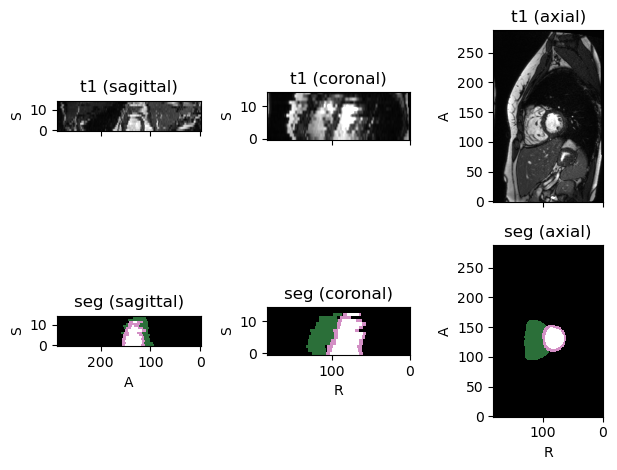

<Figure size 640x480 with 0 Axes>

In [6]:
patient_id = '085'
frame_id = '01'

subject_a = tio.Subject(
    t1=tio.ScalarImage(f'../data/ACDC/original/training/patient{patient_id}/patient{patient_id}_frame{frame_id}.nii.gz'),
    seg=tio.LabelMap(f'../data/ACDC/original/training/patient{patient_id}/patient{patient_id}_frame{frame_id}_gt.nii.gz')
)

print('Sample subject:', subject_a)
print(subject_a.t1)
print(subject_a.seg)

subject_a.plot()
plt.tight_layout()

## Preprocessing

### To Canonical

Old orientation: ('L', 'P', 'S')
New orientation: ('R', 'A', 'S')
ScalarImage(shape: (1, 184, 288, 15); spacing: (1.22, 1.22, 5.00); orientation: RAS+; dtype: torch.FloatTensor; memory: 3.0 MiB)
LabelMap(shape: (1, 184, 288, 15); spacing: (1.22, 1.22, 5.00); orientation: RAS+; dtype: torch.ByteTensor; memory: 776.2 KiB)


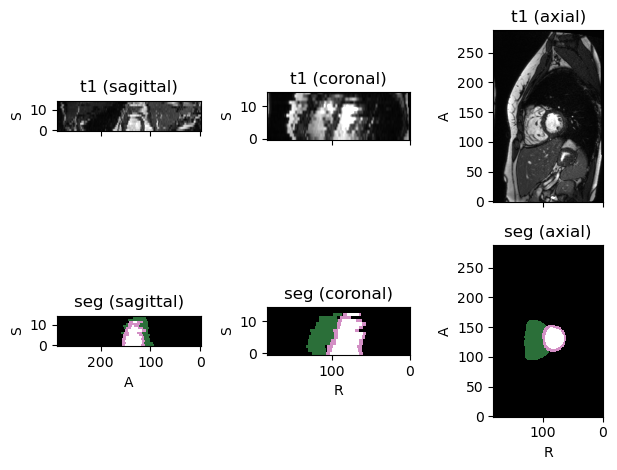

In [7]:
to_ras = tio.ToCanonical()
subject_a_ras = to_ras(subject_a)
print('Old orientation:', subject_a.t1.orientation)
print('New orientation:', subject_a_ras.t1.orientation)
print(subject_a_ras.t1)
print(subject_a_ras.seg)
subject_a_ras.plot()

### Resample

Original image: ScalarImage(shape: (1, 184, 288, 15); spacing: (1.22, 1.22, 5.00); orientation: LPS+; path: "..\data\ACDC\original\training\patient085\patient085_frame01.nii.gz")
Downsampled image: ScalarImage(shape: (1, 75, 117, 8); spacing: (3.00, 3.00, 10.00); orientation: LPS+; dtype: torch.FloatTensor; memory: 274.2 KiB)
The downsampled image takes 11.3 times less memory!


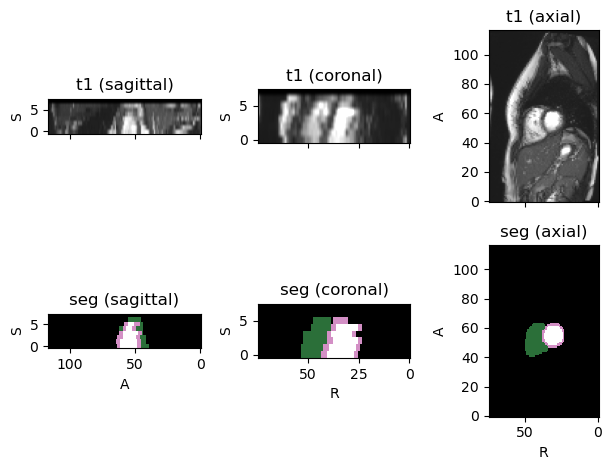

In [8]:
downsampling_factor = (4.68, 4.68, 100)
original_spacing = (1.56, 1.56, 10.00)
target_spacing = tuple(a / b for a, b in zip(downsampling_factor, original_spacing))  # in mm
downsample = tio.Resample(target_spacing)
downsampled_subject_a = downsample(subject_a)
print('Original image:', subject_a.t1)
print('Downsampled image:', downsampled_subject_a.t1)
print(f'The downsampled image takes {subject_a.t1.memory / downsampled_subject_a.t1.memory:.1f} times less memory!')

# downsampled_subject_a.t1.save('../data/ACDC/3d_imgs_augmented/patient001_frame01_aug_ds.nii.gz')
# downsampled_subject_a.seg.save('../data/ACDC/3d_imgs_augmented/patient001_frame01_gt_aug_ds.nii.gz')

downsampled_subject_a.plot()

#### Anti-aliasing

Original image: ScalarImage(shape: (1, 184, 288, 15); spacing: (1.22, 1.22, 5.00); orientation: LPS+; dtype: torch.FloatTensor; memory: 3.0 MiB)
Downsampled anti-aliasing image: ScalarImage(shape: (1, 75, 117, 8); spacing: (3.00, 3.00, 10.00); orientation: LPS+; dtype: torch.FloatTensor; memory: 274.2 KiB)


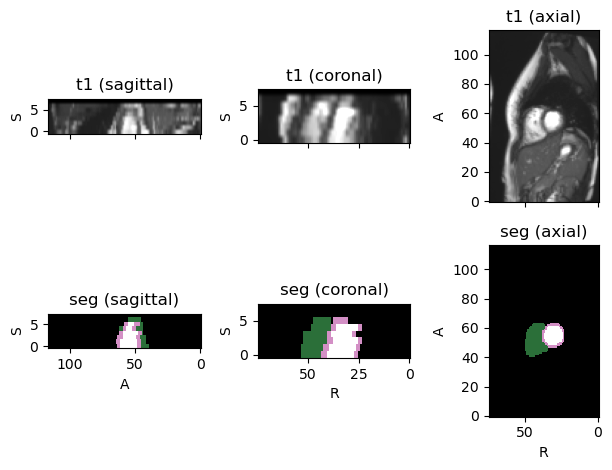

In [9]:
std = tio.Resample.get_sigma(3, 1)
antialiasing = tio.Blur(std)  # we need don't need a random transform here
blurry = antialiasing(subject_a)
downsampled_antialiasing = downsample(blurry)

print('Original image:', subject_a.t1)
print('Downsampled anti-aliasing image:', downsampled_antialiasing.t1)

downsampled_antialiasing.plot()

### Crop or Pad

In [10]:
subject_a.t1.spatial_shape

(184, 288, 15)

Original image: ScalarImage(shape: (1, 184, 288, 15); spacing: (1.22, 1.22, 5.00); orientation: LPS+; dtype: torch.FloatTensor; memory: 3.0 MiB)
Cropped/ padded image: ScalarImage(shape: (1, 128, 128, 15); spacing: (1.22, 1.22, 5.00); orientation: LPS+; dtype: torch.FloatTensor; memory: 960.0 KiB)


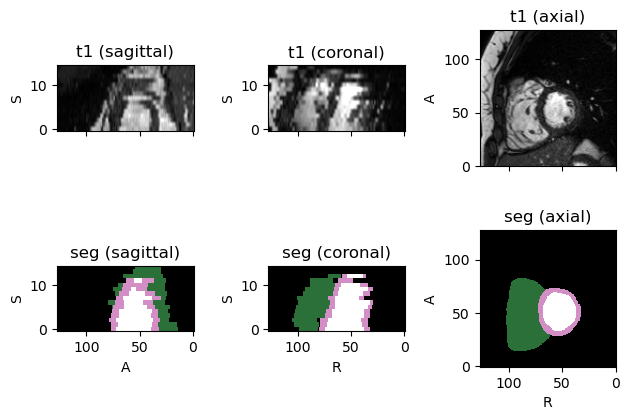

In [12]:
target_shape = 128, 128, subject_a.t1.spatial_shape[2]
crop_pad = tio.CropOrPad(target_shape)
cropped_subject_a = crop_pad(subject_a)

print('Original image:', subject_a.t1)
print('Cropped/ padded image:', cropped_subject_a.t1)

cropped_subject_a.plot()

## Augmentation

### Random Anisotropy

Applied transforms:
[Crop(cropping=(44, 44, 64, 64, 0, 0)),
 Resample(target=(1.5625, 1.5625, 15.362831354141235), image_interpolation=nearest, label_interpolation=nearest, pre_affine_name=None, scalars_only=True),
 Resample(target=((128, 128, 10), array([[  -1.5625,    0.    ,    0.    ,  -68.75  ],
       [   0.    ,   -1.5625,    0.    , -100.    ],
       [   0.    ,    0.    ,   10.    ,    0.    ],
       [   0.    ,    0.    ,    0.    ,    1.    ]])), image_interpolation=linear, label_interpolation=nearest, pre_affine_name=None, scalars_only=True)]
Original image: ScalarImage(shape: (1, 128, 128, 10); spacing: (1.56, 1.56, 10.00); orientation: LPS+; dtype: torch.ShortTensor; memory: 320.0 KiB)
Augmented image: ScalarImage(shape: (1, 128, 128, 10); spacing: (1.56, 1.56, 10.00); orientation: LPS+; dtype: torch.ShortTensor; memory: 320.0 KiB)


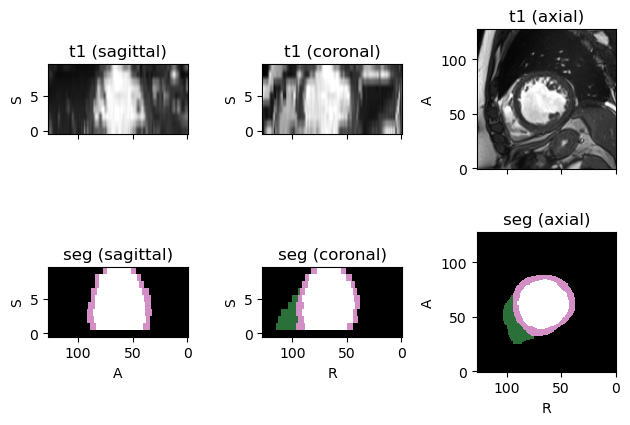

In [17]:
random_anisotropy = tio.RandomAnisotropy()
subject_a_anisotropic = random_anisotropy(cropped_subject_a)

print('Applied transforms:')
pprint.pprint(subject_a_anisotropic.history)
print('Original image:', cropped_subject_a.t1)
print('Augmented image:', subject_a_anisotropic.t1)

subject_a_anisotropic.plot()

### Random Affine

Original image: ScalarImage(shape: (1, 216, 256, 10); spacing: (1.56, 1.56, 10.00); orientation: LPS+; dtype: torch.ShortTensor; memory: 1.1 MiB)
Affined image: ScalarImage(shape: (1, 216, 256, 10); spacing: (1.56, 1.56, 10.00); orientation: LPS+; dtype: torch.FloatTensor; memory: 2.1 MiB)


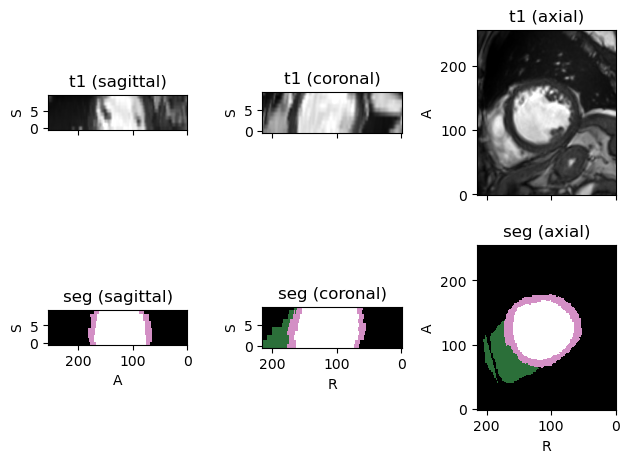

In [18]:
random_affine = tio.RandomAffine(scales=(2, 2))
slice_affine = random_affine(subject_a)

print('Original image:', subject_a.t1)
print('Affined image:', slice_affine.t1)

slice_affine.plot()

### Random Flip

Original image: ScalarImage(shape: (1, 216, 256, 10); spacing: (1.56, 1.56, 10.00); orientation: LPS+; dtype: torch.ShortTensor; memory: 1.1 MiB)
Affined image: ScalarImage(shape: (1, 216, 256, 10); spacing: (1.56, 1.56, 10.00); orientation: LPS+; dtype: torch.ShortTensor; memory: 1.1 MiB)


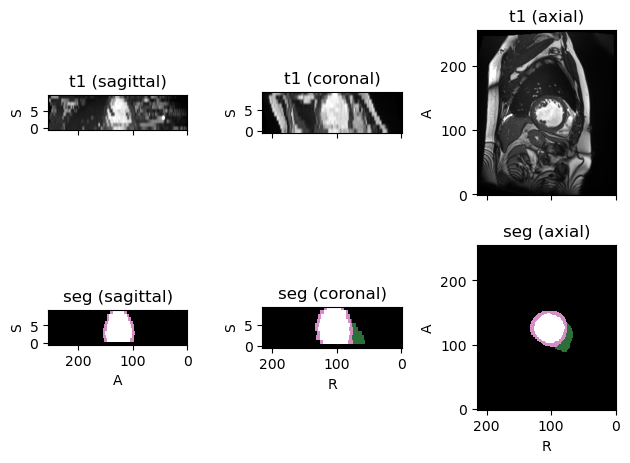

In [19]:
random_flip = tio.RandomFlip(axes=['left-right'], flip_probability=1)
subject_a_flipped = random_flip(subject_a)

print('Original image:', subject_a.t1)
print('Affined image:', subject_a_flipped.t1)

subject_a_flipped.plot()

### Random Elastic Deformation

Try different max_displacement and control points.

Original image: ScalarImage(shape: (1, 216, 256, 10); spacing: (1.56, 1.56, 10.00); orientation: LPS+; dtype: torch.ShortTensor; memory: 1.1 MiB)
Affined image: ScalarImage(shape: (1, 216, 256, 10); spacing: (1.56, 1.56, 10.00); orientation: LPS+; dtype: torch.FloatTensor; memory: 2.1 MiB)


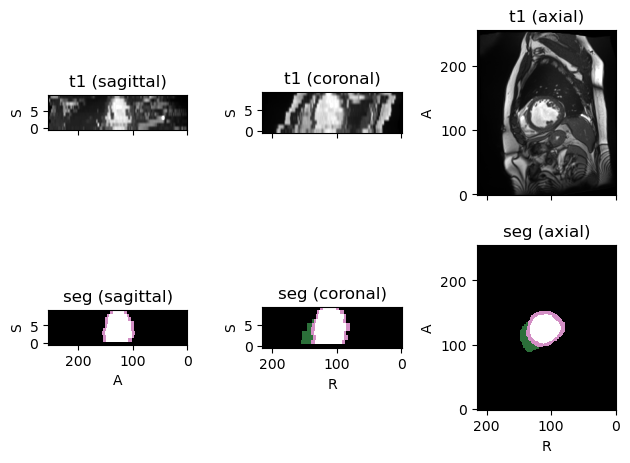

In [20]:
max_displacement = 15, 10, 0  # in x, y and z directions
random_elastic = tio.RandomElasticDeformation(max_displacement=max_displacement, num_control_points=15)
subject_a_elastic = random_elastic(subject_a)

print('Original image:', subject_a.t1)
print('Affined image:', subject_a_elastic.t1)

subject_a_elastic.plot()

### Intensity Transforms

#### Rescale Intensity

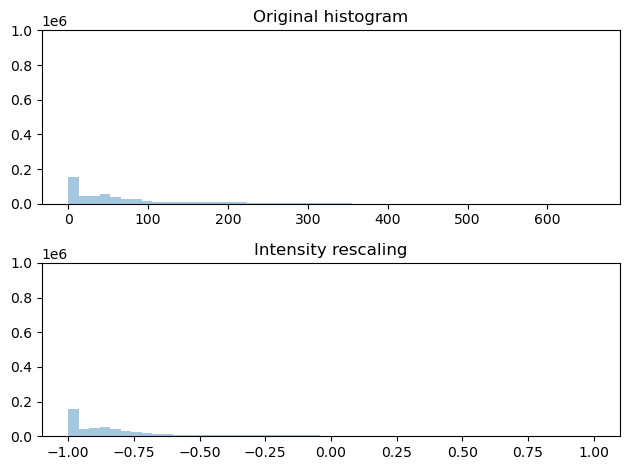

In [21]:
rescale = tio.RescaleIntensity((-1, 1))
rescaled = rescale(subject_a)
fig, axes = plt.subplots(2, 1)
sns.distplot(subject_a.t1.data, ax=axes[0], kde=False)
sns.distplot(rescaled.t1.data, ax=axes[1], kde=False)
axes[0].set_title('Original histogram')
axes[1].set_title('Intensity rescaling')
axes[0].set_ylim((0, 1e6))
axes[1].set_ylim((0, 1e6))
plt.tight_layout()

Remove the outlier intensities.

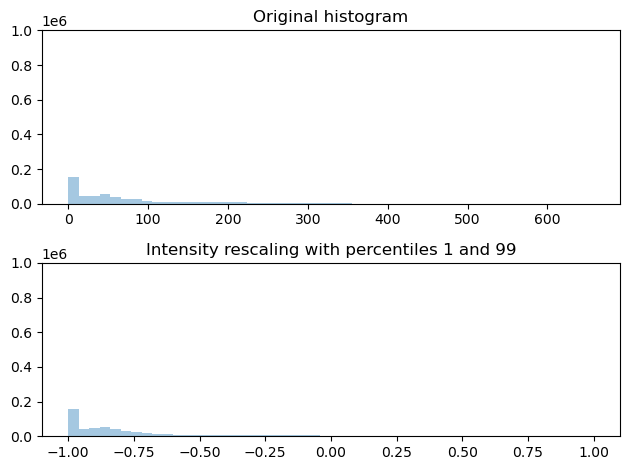

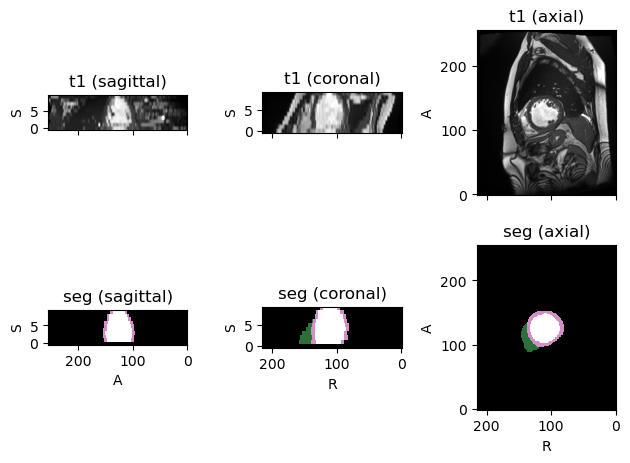

In [22]:
rescaled = rescale(subject_a_ras)
fig, axes = plt.subplots(2, 1)
sns.distplot(subject_a_ras.t1.data, ax=axes[0], kde=False)
sns.distplot(rescaled.t1.data, ax=axes[1], kde=False)
axes[0].set_title('Original histogram')
axes[1].set_title('Intensity rescaling with percentiles 1 and 99')
axes[0].set_ylim((0, 1e6))
axes[1].set_ylim((0, 1e6))
plt.tight_layout()
rescaled.plot()

#### Z-Normalization

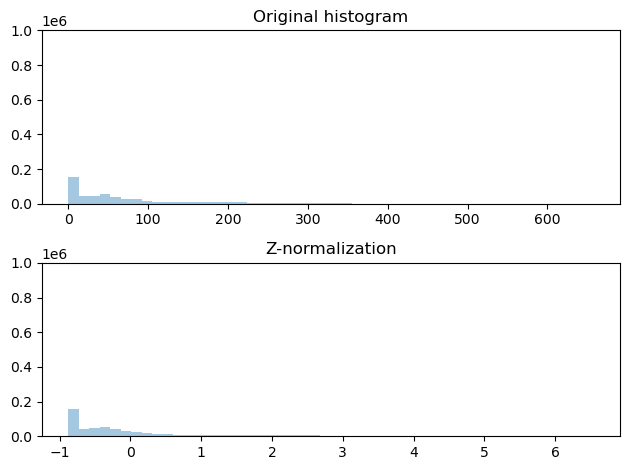

In [23]:
standardize = tio.ZNormalization()
standardized = standardize(subject_a)
fig, axes = plt.subplots(2, 1)
sns.distplot(subject_a.t1.data, ax=axes[0], kde=False)
sns.distplot(standardized.t1.data, ax=axes[1], kde=False)
axes[0].set_title('Original histogram')
axes[1].set_title('Z-normalization')
axes[0].set_ylim((0, 1e6))
axes[1].set_ylim((0, 1e6))
plt.tight_layout()

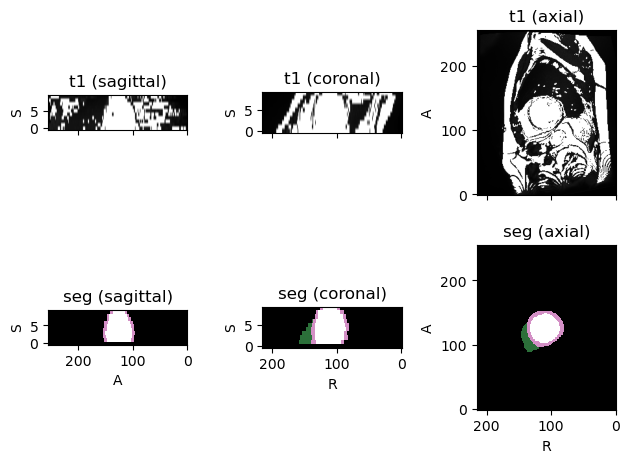

In [24]:
subject_a_thresholded = copy.deepcopy(subject_a_ras)
data = subject_a_thresholded.t1.data
data[data > data.float().mean()] = data.max()
subject_a_thresholded.plot()

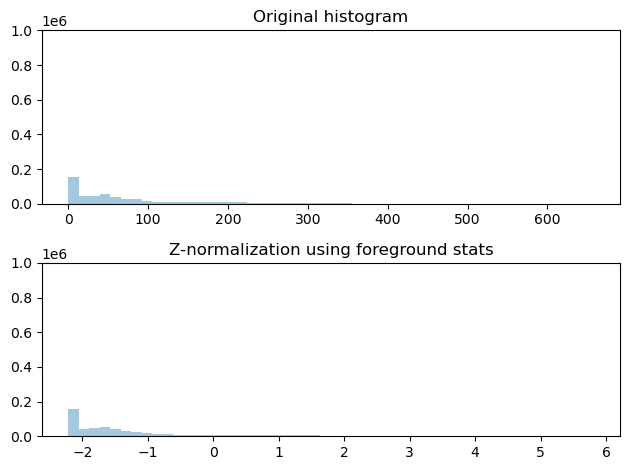

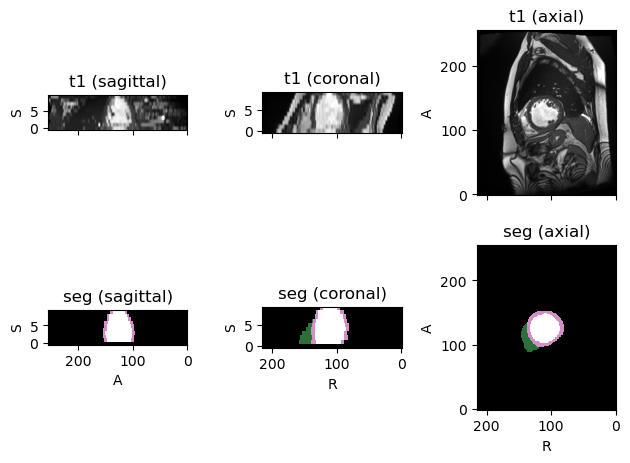

In [25]:
standardize_foreground = tio.ZNormalization(masking_method=tio.ZNormalization.mean)
standardized_foreground = standardize_foreground(subject_a)
fig, axes = plt.subplots(2, 1)
sns.distplot(subject_a.t1.data, ax=axes[0], kde=False)
sns.distplot(standardized_foreground.t1.data, ax=axes[1], kde=False)
axes[0].set_title('Original histogram')
axes[1].set_title('Z-normalization using foreground stats')
axes[0].set_ylim((0, 1e6))
axes[1].set_ylim((0, 1e6))
plt.tight_layout()
standardized_foreground.plot()

#### Random Blur

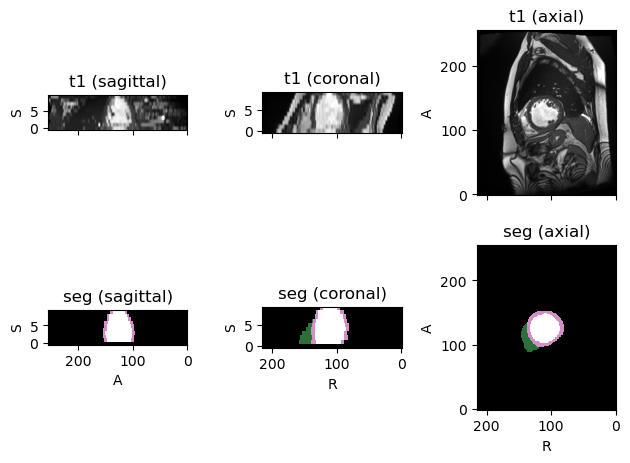

In [26]:
blur = tio.RandomBlur()
blurred = blur(subject_a_ras)
subject_a_ras.plot()

#### Random Noise

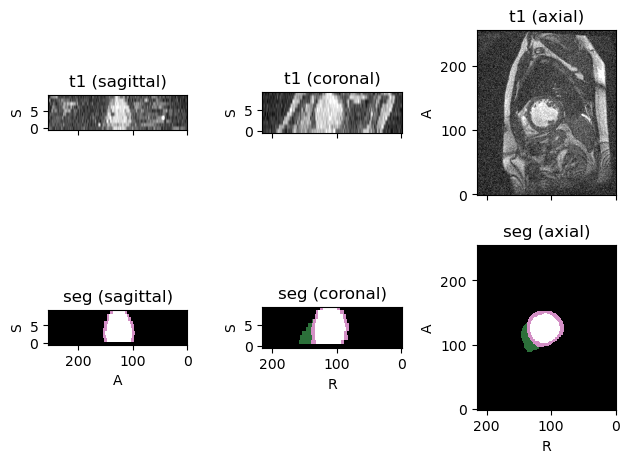

In [27]:
add_noise = tio.RandomNoise(std=0.5)
standard = standardize(subject_a_ras)
noisy = add_noise(standard)

noisy.plot()

### MRI Specific Transforms

#### Random Bias Field

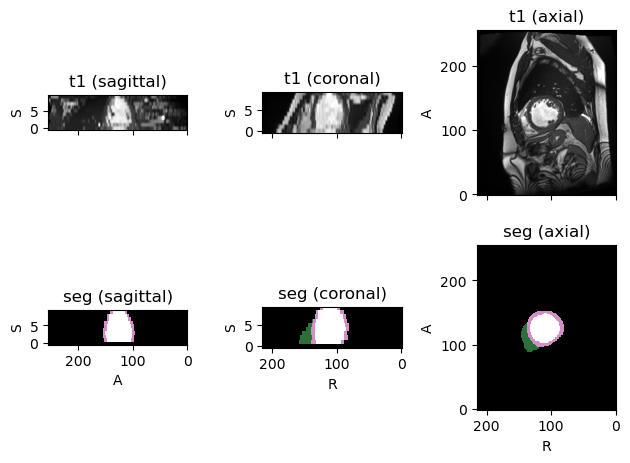

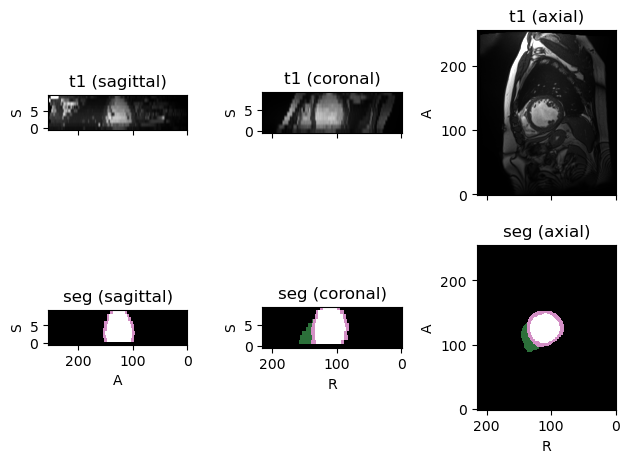

In [28]:
add_bias = tio.RandomBiasField(coefficients=1)
subject_a.seg = subject_a.t1
subject_a.plot()

mni_bias = add_bias(subject_a)
mni_bias.seg = mni_bias.t1
mni_bias.plot()

#### Random Spike

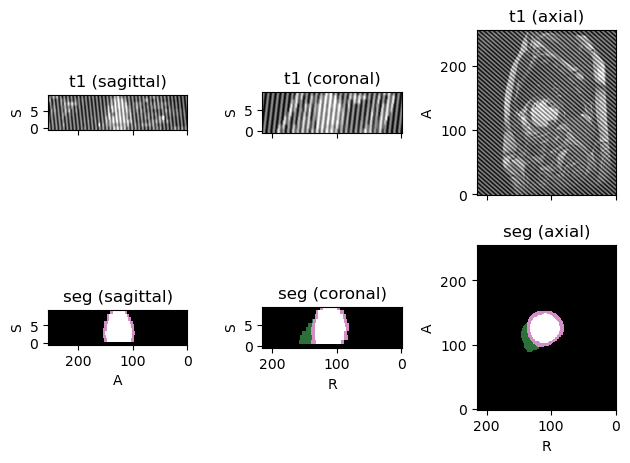

In [29]:
add_spike = tio.RandomSpike()
with_spike = add_spike(subject_a_ras)

with_spike.plot()

#### Random Ghosting

Original image: ScalarImage(shape: (1, 216, 256, 10); spacing: (1.56, 1.56, 10.00); orientation: RAS+; dtype: torch.ShortTensor; memory: 1.1 MiB)
Image with Ghosting: ScalarImage(shape: (1, 216, 256, 10); spacing: (1.56, 1.56, 10.00); orientation: RAS+; dtype: torch.FloatTensor; memory: 2.1 MiB)


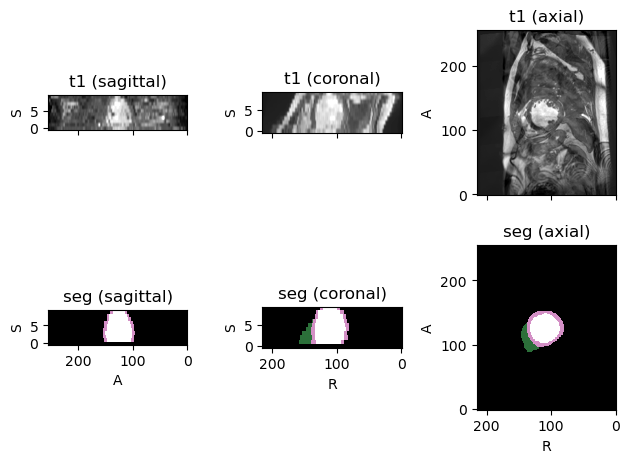

In [30]:
add_ghosts = tio.RandomGhosting(intensity=1.5)
with_ghosts = add_ghosts(subject_a_ras)

print('Original image:', subject_a_ras.t1)
print('Image with Ghosting:', with_ghosts.t1)
with_ghosts.plot()

#### Random Motion

Original image: ScalarImage(shape: (1, 216, 256, 10); spacing: (1.56, 1.56, 10.00); orientation: RAS+; dtype: torch.ShortTensor; memory: 1.1 MiB)
Image with motions: ScalarImage(shape: (1, 216, 256, 10); spacing: (1.56, 1.56, 10.00); orientation: RAS+; dtype: torch.FloatTensor; memory: 2.1 MiB)


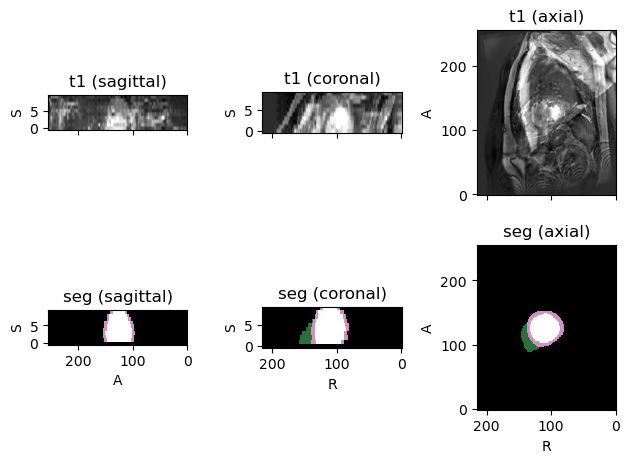

In [31]:
add_motion = tio.RandomMotion(num_transforms=1, image_interpolation='nearest')
with_motion = add_motion(subject_a_ras)

print('Original image:', subject_a_ras.t1)
print('Image with motions:', with_motion.t1)
with_motion.plot()

### Composition

Original image: ScalarImage(shape: (1, 216, 256, 10); spacing: (1.56, 1.56, 10.00); orientation: LPS+; dtype: torch.ShortTensor; memory: 1.1 MiB)
Transformed image: ScalarImage(shape: (1, 113, 134, 10); spacing: (3.00, 3.00, 10.00); orientation: RAS+; dtype: torch.ShortTensor; memory: 295.7 KiB)


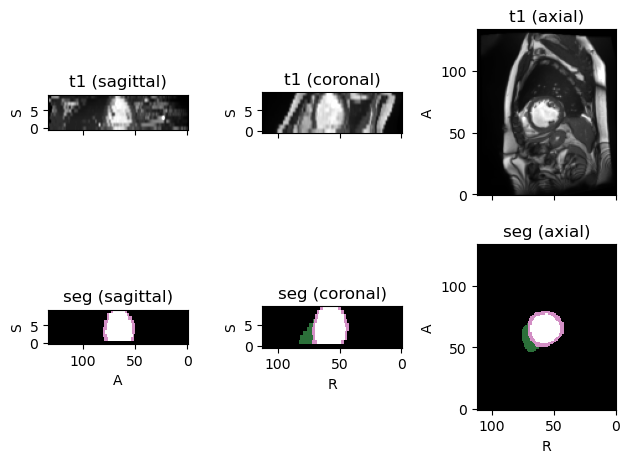

In [32]:
nice_downsample = tio.Compose([
    to_ras,
    antialiasing,
    downsample,                   
])
nice_down = nice_downsample(subject_a)

print('Original image:', subject_a.t1)
print('Transformed image:', nice_down.t1)
nice_down.plot()

# Augment ACDC Dataset

In [4]:
def save_images(subject_3d_img, op_patient_dir_, patient_frame_id_, operation_):
    # Create patientXXX directory if not exist
    if not os.path.exists(op_patient_dir_):
        os.makedirs(op_patient_dir_)
    
    subject_3d_img.t1.save(os.path.join(op_patient_dir_, f"{patient_frame_id_}_{operation_}.nii.gz"))
    subject_3d_img.seg.save(os.path.join(op_patient_dir_, f"{patient_frame_id_}_{operation_}_gt.nii.gz"))

In [5]:
sets = ['training', 'validation', 'testing']
# sets = ['training']
org_dataset_path = "../data/ACDC/original/"
aug_dataset_path = "../data/ACDC/3d_imgs_augmented_v4/"

for set_ in sets:
    ip_set_path = os.path.join(org_dataset_path, set_)
    op_set_path = os.path.join(aug_dataset_path, set_)
    patient_dirs = [d for d in os.listdir(ip_set_path) if os.path.isdir(os.path.join(ip_set_path, d))]
    for patient_ in patient_dirs:
        ip_patient_dir = os.path.join(ip_set_path, patient_)
        op_patient_dir = os.path.join(op_set_path, patient_)
        
        # Create output directory
        if not os.path.exists(op_patient_dir):
            os.makedirs(op_patient_dir)
        
        # Copy Info.cfg file to output directory
        src_info_file_path = os.path.join(ip_patient_dir, 'Info.cfg')
        dst_info_file_path = os.path.join(op_patient_dir, 'Info.cfg')
        info_file_path = shutil.copy(src_info_file_path, dst_info_file_path)
        
        # Regular expression to match the pattern "patientxxx_framexx"
        pattern = re.compile(r'patient\d{3}_frame\d{2}(?=\.nii.gz)')
        
        # List to store the matched IDs
        patient_frame_ids = []
        
        # Iterate through files in the directory
        for file in os.listdir(ip_patient_dir):
            match = pattern.match(file)
            if match:
                patient_frame_id = match.group()
                patient_frame_ids.append(patient_frame_id)
        
                org_subject = tio.Subject(
                    t1=tio.ScalarImage(os.path.join(ip_patient_dir, f"{patient_frame_id}.nii.gz")),
                    seg=tio.LabelMap(os.path.join(ip_patient_dir, f"{patient_frame_id}_gt.nii.gz"))
                )
                
                '''
                # Crop the image
                target_shape = 128, 128, org_subject.t1.spatial_shape[2]
                crop_pad = tio.CropOrPad(target_shape)
                cropped_subject_a = crop_pad(org_subject)
                '''
                
                # To Canonical
                to_ras = tio.ToCanonical()
                org_subject_ras = to_ras(org_subject)
                save_images(org_subject_ras, op_patient_dir, patient_frame_id, operation_='ras')
                
                # Random Anisotropy
                random_anisotropy = tio.RandomAnisotropy()
                org_sub_anisotropic = random_anisotropy(org_subject_ras)
                save_images(org_sub_anisotropic, op_patient_dir, patient_frame_id, operation_='ran_anis')
                
                # Random Affine
                random_affine = tio.RandomAffine(scales=(0.9, 1.2), degrees=3)
                org_sub_affine = random_affine(org_subject_ras)
                save_images(org_sub_affine, op_patient_dir, patient_frame_id, operation_='ran_aff')
                
                # Random Flip
                random_flip = tio.RandomFlip(axes=['left-right'], flip_probability=1)
                org_sub_flipped = random_flip(org_subject_ras)
                save_images(org_sub_flipped, op_patient_dir, patient_frame_id, operation_='ran_flip')
                
                # Random Elastic Deformation
                max_displacement = 15, 10, 0  # in x, y and z directions
                random_elastic = tio.RandomElasticDeformation(max_displacement=max_displacement, num_control_points=15)
                org_sub_elastic = random_elastic(org_subject_ras)
                save_images(org_sub_elastic, op_patient_dir, patient_frame_id, operation_='ran_elas')
                
                # Random Blur
                blur = tio.RandomBlur()
                org_sub_blurred = blur(org_subject_ras)
                save_images(org_sub_blurred, op_patient_dir, patient_frame_id, operation_='ran_blur')
                
                '''
                # Random Noise
                add_noise = tio.RandomNoise(std=0.5)
                standardize = tio.ZNormalization()
                standard = standardize(org_subject_ras)
                org_sub_noisy = add_noise(standard)
                save_images(org_sub_noisy, op_patient_dir, patient_frame_id, operation_='ran_noise')
                
                # Random Spike
                add_spike = tio.RandomSpike()
                org_sub_spike = add_spike(org_subject_ras)
                save_images(org_sub_spike, op_patient_dir, patient_frame_id, operation_='ran_spike')
                
                
                # Random Ghosting
                add_ghosts = tio.RandomGhosting(intensity=1.5)
                org_sub_ghosts = add_ghosts(org_subject_ras)
                save_images(org_sub_ghosts, op_patient_dir, patient_frame_id, operation_='ran_gho')
                
                
                # Random Motion
                add_motion = tio.RandomMotion(num_transforms=1, image_interpolation='nearest')
                org_sub_motion = add_motion(org_subject_ras)
                save_images(org_sub_motion, op_patient_dir, patient_frame_id, operation_='ran_mot')
                '''
                
                # Random Bias Field
                add_bias = tio.RandomBiasField(coefficients=1)
                org_sub_bias = add_bias(org_subject_ras)
                save_images(org_sub_bias, op_patient_dir, patient_frame_id, operation_='ran_bias')
    